### Step 1: Install necesscary packages

In [1]:
!pip install matplotlib
!pip install torch numpy transformers datasets tiktoken wandb tqdm

### Step 2: Package imports and configuration

---
Purpose
- Prepare environment, imports, device, hyperparameters, and tokenizer utilities required by later cells.

Hyperparameters
- Defines beta, base_lr, epochs, batch_size, max_length, num_samples, max_new_tokens, temperature, top_k.

Tokenizer & sanitization
- Loads ../sft/meta.pkl to obtain stoi/itos and provides encode/decode helpers.
- Builds allowed_chars from stoi; sanitize(s, replacement="") removes or replaces OOV characters.
- find_oov_characters(pairs) scans dataset pairs for unseen characters.

---

In [ ]:
import sys
import os
sys.path.append(os.path.abspath("..")) 
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import pickle
from model import GPT, GPTConfig
from tqdm import tqdm
import time
import json
import matplotlib.pyplot as plt

# Configuration
beta = 0.5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
base_lr = 1e-4
epochs = 5
batch_size = 64
max_length =64
num_samples = 1
max_new_tokens = 200
temperature = 0.8
top_k = 200

# tokenizer
with open("../sft/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi, itos = meta["stoi"], meta["itos"]
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])

# --- ADD THIS BLOCK ---
allowed_chars = set(stoi.keys())

def sanitize(s: str, *, replacement=""):  # replacement="" drops OOV chars
    # Keep only characters known to the tokenizer
    return ''.join((ch if ch in allowed_chars else replacement) for ch in s)

# Optional: quick OOV scan to see what's in your data
def find_oov_characters(pairs):
    oov = set()
    for p in pairs:
        for s in (p['negative'], p['positive']):
            for ch in s:
                if ch not in allowed_chars:
                    oov.add(ch)
    return oov
# ----------------------


### Step 3: Define helper functions

---
Batch Structure
- Each batch contains two tensors:
    - `neg_tensor`: less preferred responses
    - `pos_tensor`: preferred responses
- Shape: (B, T) where:
    - B = batch size
    - T = maximum sequence length

Data Processing Steps
1. Input Preparation

- Sanitize input strings (remove invalid characters)
- Add 4 newlines as sequence terminators
- Convert to token IDs

2. Sequence Processing

- Pad/truncate sequences to max length
- Use padding token (0) for shorter sequences
- Keep most recent tokens if truncating

---

In [ ]:
def compute_logprob(input_ids):
    inputs = input_ids[:, :-1]
    targets = input_ids[:, 1:]
    logits, _ = gpt(inputs, full_seq=True)
    B, T, V = logits.size()
    logits_flat = logits.reshape(-1, V)
    targets_flat = targets.reshape(-1)
    # Negative loss equals log-probability
    loss = F.cross_entropy(logits_flat, targets_flat, ignore_index=0, reduction='none')
    loss = loss.reshape(B, T)
    attention_mask = (targets != 0).float()
    loss = (loss * attention_mask).sum(dim=1) / attention_mask.sum(dim=1)
    return -loss 

# padding or truncating sequences to max_length
def pad_or_truncate(seq, max_length):
    return seq[-max_length:] if len(seq) > max_length else seq + [0] * (max_length - len(seq))

def get_batches(lines, batch_size):
    # Append newline padding before truncation and convert to tensors
    random.shuffle(lines)
    #for l in lines:
    #    print(l[1])
    for i in range(0, len(lines), batch_size):
        batch = lines[i:i+batch_size]
        if len(batch) < batch_size:
            continue
        neg_inputs = [pad_or_truncate(encode(sanitize(p['negative']) + '\n\n\n\n'), max_length) for p in batch]
        pos_inputs = [pad_or_truncate(encode(sanitize(p['positive']) + '\n\n\n\n'), max_length) for p in batch]
        neg_tensor = torch.tensor(neg_inputs, dtype=torch.long, device=device)
        pos_tensor = torch.tensor(pos_inputs, dtype=torch.long, device=device)
        yield neg_tensor, pos_tensor

### Step 4: Load the pretrained NanoGPT model

In [ ]:
ckpt = torch.load("../sft/gpt.pt", map_location=device)
gptconf = GPTConfig(**ckpt['model_args'])
gpt = GPT(gptconf)
state_dict = ckpt['model']
unwanted_prefix = '_orig_mod.'
for k in list(state_dict.keys()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
gpt.load_state_dict(state_dict)
gpt.to(device).train()

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(74, 348)
    (wpe): Embedding(256, 348)
    (drop): Dropout(p=0.2, inplace=False)
    (h): ModuleList(
      (0-5): 6 x Block(
        (ln_1): LayerNorm()
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=348, out_features=1044, bias=False)
          (c_proj): Linear(in_features=348, out_features=348, bias=False)
          (attn_dropout): Dropout(p=0.2, inplace=False)
          (resid_dropout): Dropout(p=0.2, inplace=False)
        )
        (ln_2): LayerNorm()
        (mlp): MLP(
          (c_fc): Linear(in_features=348, out_features=1392, bias=False)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=1392, out_features=348, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm()
  )
  (lm_head): Linear(in_features=348, out_features=74, bias=False)
)

### Step 5: Load Data (**students are required to complete this part!**)

In [5]:
# Load data from ./data/pos_neg_pairs.json
import json

with open("../dpo/pos_neg_pairs.json", "r") as f:
    lines = json.load(f)

### Step 6: Build the optimizer and scheduler (**students are required to complete this part!**)

In [ ]:
# recommended to use the AdamW optimizer 

optimizer = torch.optim.AdamW(gpt.parameters(), lr=base_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * (len(lines) // batch_size), eta_min=1e-5)

### Step 7: Begin training (**students are required to complete this part!**)

---
The training loop implements DPO by maximizing the log-prob of preferred responses while minimizing non-preferred ones. The loss combines two terms:

1. A preference gap term using log-sigmoid to encourage pos_logprob > neg_logprob
2. A regularization term (0.1 * pos_logprob) to maintain language modeling capabilities

Key Components:
- Tracks losses for visualization
- Performs gradient clipping at 1.0
- Applies learning rate scheduling
---

Epoch 1/5 Loss: 0.0264 LR: 0.000091: : 6250it [1:44:03,  1.00it/s]


Epoch 1 Average loss: 0.0382
Saved checkpoint to ./dpo.pt


Epoch 2/5 Loss: 0.0220 LR: 0.000069: : 6250it [1:44:12,  1.00s/it]


Epoch 2 Average loss: 0.0248
Saved checkpoint to ./dpo.pt


Epoch 3/5 Loss: 0.0212 LR: 0.000041: : 6250it [1:43:49,  1.00it/s]


Epoch 3 Average loss: 0.0220
Saved checkpoint to ./dpo.pt


Epoch 4/5 Loss: 0.0208 LR: 0.000019: : 6250it [1:45:08,  1.01s/it]


Epoch 4 Average loss: 0.0210
Saved checkpoint to ./dpo.pt


Epoch 5/5 Loss: 0.0218 LR: 0.000010: : 6250it [1:45:54,  1.02s/it]


Epoch 5 Average loss: 0.0205
Saved checkpoint to ./dpo.pt


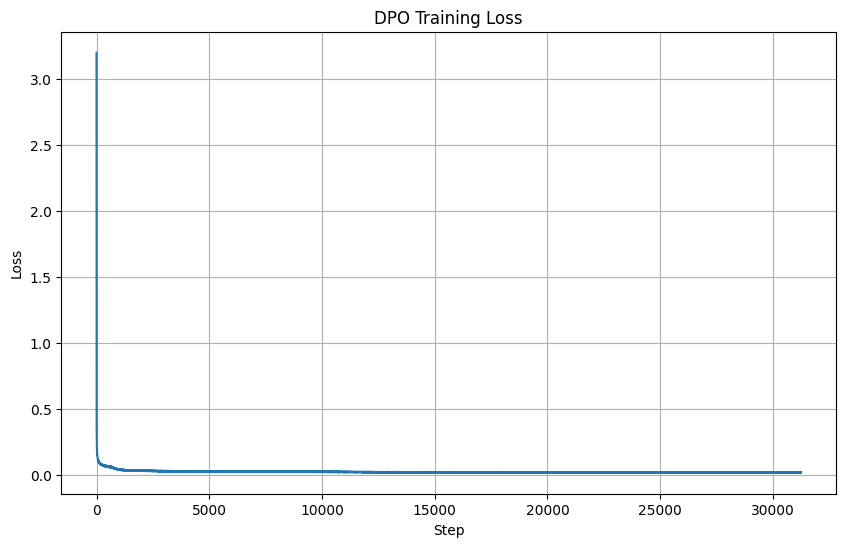

In [ ]:
# Calculate total steps per epoch (dataset size / batch size)
total_steps = len(lines) // batch_size
losses = []

for epoch in range(epochs):
    pbar = tqdm(get_batches(lines, batch_size))
    epoch_loss = 0
    for step, (neg_tensor,pos_tensor) in enumerate(pbar):
        optimizer.zero_grad()
        
        # Compute log probabilities for both preferred and non-preferred response
        neg_logprob = compute_logprob(neg_tensor)
        pos_logprob = compute_logprob(pos_tensor)
        
        # DPO loss = -log(σ((pos_prob - neg_prob)/β)) - 0.1*pos_prob
        # First term: preference learning, Second term: language model regularization
        loss = -F.logsigmoid((pos_logprob - neg_logprob) / beta).mean() - pos_logprob.mean() * 0.1 
        
        loss.backward()
        # clip the gradient
        torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        # tracking loss
        epoch_loss += loss.item()
        losses.append(loss.item())
        
        pbar.set_description(f"Epoch {epoch+1}/{epochs} Loss: {loss.item():.4f} LR: {scheduler.get_last_lr()[0]:.6f}")
        
    print(f"Epoch {epoch+1} Average loss: {epoch_loss/total_steps:.4f}")
        
    # Save checkpoint    
    ckpt_path = f"./dpo.pt"
    torch.save({
        "model_state_dict": gpt.state_dict(),
        "model_args": ckpt['model_args'],
    }, ckpt_path)
    print(f"Saved checkpoint to {ckpt_path}")
    
# Plotting the loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('DPO Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


Initial Phase
- Sharp drop in first few steps
- Shows model quickly learning basic preferences

Middle Phase
- Gradual, consistent decrease

Final Phase
- Curve levels off and starts flattening
- Indicates model reaching stable performance
---

### Step 8: Begin testing (**students are required to complete this part!**)

In [ ]:
# Load the fine-tuned model
ckpt_path = f"./dpo.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
gptconf = GPTConfig(**checkpoint['model_args'])
gpt = GPT(gptconf).to(device)
try:
    state_dict = checkpoint['model']
except:
    state_dict = checkpoint['model_state_dict']
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
gpt.load_state_dict(state_dict)

# Test

gpt.eval()
test_set = ["1+x=5", "3*14=?", "80/4=?", "20+12=?", "38-8=?","60/x =10, x=?", "24-10=?", "4*x=20, x=?", "135+561=?"]

with torch.no_grad():
    for prompt in test_set:
        prompt_ids = encode(sanitize(prompt))
        x = torch.tensor([prompt_ids], dtype=torch.long, device=device)

        # Deterministic decode WITHOUT modifying model.py:
        # keep temperature > 0, and set top_k=1 (greedy via top-1 filter)
        # Ensures highest probability token is chosen
        y = gpt.generate(x, max_new_tokens, temperature=1.0, top_k=1)

        tokens = y[0] if isinstance(y, tuple) else y
        toks = tokens[0].tolist()
        gen_only = toks[len(prompt_ids):]
        text = decode(gen_only)
        print(f"Prompt: {prompt}\nResponse:{text}\n{'='*40}")


# Test
#gpt.eval()
#test_set = ["17+19=?", "3*17=?", "72/4=?", "72-34=?", "x*11=44,x=?"]

'''
with torch.no_grad():
    for prompt in test_set:
        prompt_ids = encode(sanitize(prompt))
        x = torch.tensor([prompt_ids], dtype=torch.long, device=device)

        # GREEDY decode: no randomness
        y = gpt.generate(x, max_new_tokens, temperature=0.0, top_k=None)

        tokens = y[0] if isinstance(y, tuple) else y
        toks = tokens[0].tolist()
        gen_only = toks[len(prompt_ids):]
        text = decode(gen_only)
        print(f"Prompt: {prompt}\nResponse:{text}\n{'='*40}")

        '''


Prompt: 1+x=5
Response:, x=? The answer is 4 because x = 5-1 = 4.
Prompt: 3*14=?
Response: The answer is 42 because 3*14 equals 42.
Prompt: 80/4=?
Response: The answer is 20 because 80/4 equals 20.
Prompt: 20+12=?
Response: The answer is 32 because 20+12 equals 32.
Prompt: 38-8=?
Response: The answer is 30 because 38-8 equals 30.
Prompt: 60/x =10, x=?
Response: The answer is 60 because x = 60/10 = 6.
Prompt: 24-10=?
Response: The answer is 14 because 24-10 equals 14.
Prompt: 4*x=20, x=?
Response: The answer is 5 because x = 20/4 = 5.
Prompt: 135+561=?
Response: The answer is 696 because 135+561 equals 696.


'\nwith torch.no_grad():\n    for prompt in test_set:\n        prompt_ids = encode(sanitize(prompt))\n        x = torch.tensor([prompt_ids], dtype=torch.long, device=device)\n\n        # GREEDY decode: no randomness\n        y = gpt.generate(x, max_new_tokens, temperature=0.0, top_k=None)\n\n        tokens = y[0] if isinstance(y, tuple) else y\n        toks = tokens[0].tolist()\n        gen_only = toks[len(prompt_ids):]\n        text = decode(gen_only)\n        print(f"Prompt: {prompt}\nResponse:{text}\n{\'=\'*40}")\n\n        '

In [23]:
gpt.eval()
test_set = ["5+8=?", "9+8=?", "144/12=?", "15-4=?","45/x=9, x=?", "3*x=21, x=?", "x+6=10, x=?", "x-5=20, x=?", "250+375=?"]

with torch.no_grad():
    for prompt in test_set:
        prompt_ids = encode(sanitize(prompt))
        x = torch.tensor([prompt_ids], dtype=torch.long, device=device)

        # Deterministic decode WITHOUT modifying model.py:
        # keep temperature > 0, and set top_k=1 (greedy via top-1 filter)
        y = gpt.generate(x, max_new_tokens, temperature=1.0, top_k=1)

        tokens = y[0] if isinstance(y, tuple) else y
        toks = tokens[0].tolist()
        gen_only = toks[len(prompt_ids):]
        text = decode(gen_only)
        print(f"Prompt: {prompt}\nResponse:{text}\n{'='*40}")


Prompt: 5+8=?
Response: The answer is 13 because 5+8 equals 13.
Prompt: 9+8=?
Response: The answer is 17 because 9+8 equals 17.
Prompt: 144/12=?
Response: The answer is 12 because 144/12 equals 12.
Prompt: 15-4=?
Response: The answer is 11 because 15-4 equals 11.
Prompt: 45/x=9, x=?
Response: The answer is 5 because x = 45/9 = 5.
Prompt: 3*x=21, x=?
Response: The answer is 7 because x = 21/3 = 7.
Prompt: x+6=10, x=?
Response: The answer is 4 because 4+6=10, so x=10-6=4.
Prompt: x-5=20, x=?
Response: The answer is 25 because 25-5=20, so x=20+5=25.
Prompt: 250+375=?
Response: The answer is 625 because 250+375 equals 625.


In [27]:
gpt.eval()
test_set = [
    "11+13=?", "45-27=?", "8*9=?", "100/25=?", "x+9=15, x=?", "3*x=18, x=?", "50/x=5, x=?", "x-4=11, x=?", "120+480=?", "9*12=?",
    "81/9=?", "x/4=3, x=?", "4*x+2=14, x=?", "36/6=?", "x-8=20, x=?", "x/5=9, x=?"]

with torch.no_grad():
    for prompt in test_set:
        prompt_ids = encode(sanitize(prompt))
        x = torch.tensor([prompt_ids], dtype=torch.long, device=device)

        # Deterministic decode WITHOUT modifying model.py:
        # keep temperature > 0, and set top_k=1 (greedy via top-1 filter)
        y = gpt.generate(x, max_new_tokens, temperature=1.0, top_k=1)

        tokens = y[0] if isinstance(y, tuple) else y
        toks = tokens[0].tolist()
        gen_only = toks[len(prompt_ids):]
        text = decode(gen_only)
        print(f"Prompt: {prompt}\nResponse:{text}\n{'='*40}")

Prompt: 11+13=?
Response: The answer is 24 because 11+13 equals 24.
Prompt: 45-27=?
Response: The answer is 18 because 45-27 equals 18.
Prompt: 8*9=?
Response: The answer is 72 because 8*9 equals 72.
Prompt: 100/25=?
Response: The answer is 4 because 100/25 equals 4.
Prompt: x+9=15, x=?
Response: The answer is 6 because 6+9=15, so x=15-9=6.
Prompt: 3*x=18, x=?
Response: The answer is 6 because x = 18/3 = 6.
Prompt: 50/x=5, x=?
Response: The answer is 10 because x = 50/5 = 10.
Prompt: x-4=11, x=?
Response: The answer is 15 because 15-4=11, so x=11+4=15.
Prompt: 120+480=?
Response: The answer is 600 because 120+480 equals 600.
Prompt: 9*12=?
Response: The answer is 108 because 9*12 equals 108.
Prompt: 81/9=?
Response: The answer is 9 because 81/9 equals 9.
Prompt: x/4=3, x=?
Response: The answer is 12 because x = 4*3 = 12.
Prompt: 4*x+2=14, x=?
Response: The answer is 3 because x = 14-2/4 = 3.
Prompt: 36/6=?
Response: The answer is 6 because 36/6 equals 6.
Prompt: x-8=20, x=?
Response: T